### Phase 2: Feature Engineering

In [55]:
# =====================================================
# PHASE 2 — FEATURE ENGINEERING (TECH + NEWS)
# =====================================================

import os
import logging
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

%load_ext nb_black

The nb_black extension is already loaded. To reload it, use:
  %reload_ext nb_black


<IPython.core.display.Javascript object>

In [56]:
# -----------------------------------------------------
# Step 1: Setup paths & logging
# -----------------------------------------------------

PROJECT_ROOT = Path().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FEATURE_DIR = PROJECT_ROOT / "data" / "features"
NEWS_DIR = PROJECT_ROOT / "data" / "news_raw"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(level=logging.WARNING)

DATASET_DIR = DATA_DIR / "datasets"
DATASET_DIR.mkdir(parents=True, exist_ok=True)

print(f"📈 Found {len(list(DATA_DIR.glob('*.csv')))} raw files.")


📈 Found 100 raw files.


<IPython.core.display.Javascript object>

In [57]:
# -----------------------------------------------------
# Step 2: Technical Indicator Functions
# -----------------------------------------------------

def compute_technical_features(df):

    df = df.sort_values("Date").copy()
    
    df["ret_1d"] = df["Close"].pct_change()
    df["ret_5d"] = df["Close"].pct_change(5)
    df["ret_21d"] = df["Close"].pct_change(21)

    df["momentum_1m"] = df["Close"].pct_change(21)
    df["momentum_3m"] = df["Close"].pct_change(63)
    df["momentum_6m"] = df["Close"].pct_change(126)

    df["vol_30d"] = df["ret_1d"].rolling(30).std().shift(1)
    df["vol_90d"] = df["ret_1d"].rolling(90).std().shift(1)

    delta = df["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()

    rs = avg_gain / avg_loss
    df["rsi_14"] = (100 - (100 / (1 + rs))).shift(1)

    ema12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema26 = df["Close"].ewm(span=26, adjust=False).mean()

    df["macd"] = (ema12 - ema26).shift(1)
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean().shift(1)
    df["macd_hist"] = (df["macd"] - df["macd_signal"]).shift(1)

    df["ema_fast"] = df["Close"].ewm(span=20, adjust=False).mean()
    df["ema_slow"] = df["Close"].ewm(span=50, adjust=False).mean()

    df["ema_cross"] = (df["ema_fast"] > df["ema_slow"]).astype(int).shift(1)

    df["volume_change"] = df["Volume"].pct_change().shift(1)

    vol_mean = df["Volume"].rolling(30).mean()
    vol_std = df["Volume"].rolling(30).std()

    df["volume_zscore"] = ((df["Volume"] - vol_mean) / vol_std).shift(1)
    df["volume_momentum"] = (df["Volume"] / df["Volume"].rolling(21).mean()).shift(1)

    rolling_high = df["High"].rolling(20).max()
    rolling_low = df["Low"].rolling(20).min()

    df["range_position"] = (
        (df["Close"] - rolling_low) / (rolling_high - rolling_low)
    ).shift(1)

    df["ret_skew_10"] = df["ret_1d"].rolling(10).skew().shift(1)
    df["ret_kurt_10"] = df["ret_1d"].rolling(10).kurt().shift(1)
    df["ret_skew_30"] = df["ret_1d"].rolling(30).skew().shift(1)
    df["ret_kurt_30"] = df["ret_1d"].rolling(30).kurt().shift(1)

    return df


<IPython.core.display.Javascript object>

In [58]:
# -----------------------------------------------------
# Step 2.5: News Feature Engineering (LEAKAGE-FREE)
# -----------------------------------------------------


def load_and_engineer_news(symbol):

    news_file = NEWS_DIR / f"{symbol}_news.csv"

    if not news_file.exists():
        return None

    df = pd.read_csv(news_file)

    if df.empty:
        return None

    df["Date"] = pd.to_datetime(df["date"], errors="coerce")
    df.dropna(subset=["Date"], inplace=True)

    if "sentiment_score" not in df.columns:
        return None

    # -------------------------------------------------
    # 🔹 Daily Aggregation
    # -------------------------------------------------

    daily = (
        df.groupby("Date")
        .agg(
            news_sent=("sentiment_score", "mean"),
            news_count=("sentiment_score", "count"),
        )
        .reset_index()
        .sort_values("Date")
    )

    # -------------------------------------------------
    # 🔹 SHIFT (CRITICAL FOR LEAKAGE PREVENTION)
    # -------------------------------------------------

    daily["news_sent_lag1"] = daily["news_sent"].shift(1)
    daily["news_count_lag1"] = daily["news_count"].shift(1)

    # -------------------------------------------------
    # 🔹 Rolling Features (ONLY PAST DATA)
    # -------------------------------------------------

    daily["sent_3d"] = daily["news_sent_lag1"].rolling(3).mean()
    daily["sent_7d"] = daily["news_sent_lag1"].rolling(7).mean()

    # Momentum
    daily["sent_momentum"] = daily["sent_3d"] - daily["sent_7d"]

    # -------------------------------------------------
    # 🔹 Sentiment Surprise
    # -------------------------------------------------

    daily["sent_roll_mean"] = daily["news_sent_lag1"].rolling(7, min_periods=1).mean()

    daily["sent_surprise"] = daily["news_sent_lag1"] - daily["sent_roll_mean"]

    # -------------------------------------------------
    # 🔹 News Intensity
    # -------------------------------------------------

    daily["news_count_ma7"] = daily["news_count_lag1"].rolling(7).mean()

    daily["news_intensity"] = daily["news_count_lag1"] / daily["news_count_ma7"]

    # -------------------------------------------------
    # 🔹 Final Features (drop raw lag columns if you want)
    # -------------------------------------------------

    return daily

<IPython.core.display.Javascript object>

In [59]:
# -----------------------------------------------------
# Clean feature directory
# -----------------------------------------------------

for f in FEATURE_DIR.glob("*.csv"):
    f.unlink()

print("🧹 Cleared old feature files")


🧹 Cleared old feature files


<IPython.core.display.Javascript object>

In [67]:
# -----------------------------------------------------
# Step 3: Process Each Ticker
# -----------------------------------------------------

all_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".csv")]
print(f"📈 Processing {len(all_files)} tickers...")

all_ticker_dfs = []

final_news_features = [
    "news_sent",
    "news_count",
    "sent_3d",
    "sent_7d",
    "sent_momentum",
    "sent_surprise",
    "news_intensity",
    "news_event",
    "days_since_news",
    "news_decay_weight",
    "sent_weighted",
    "surprise_weighted",
    "is_recent_news",
]

for file in tqdm(all_files):
    try:
        file_path = DATA_DIR / file
        symbol = file.replace(".csv", "")

        df = pd.read_csv(file_path)
        df.columns = [c.strip().lower() for c in df.columns]

        col_map = {
            "date": "Date",
            "openprice": "Open",
            "open": "Open",
            "highprice": "High",
            "high": "High",
            "lowprice": "Low",
            "low": "Low",
            "closeprice": "Close",
            "close": "Close",
            "totaltradedquantity": "Volume",
            "volume": "Volume",
        }

        df.rename(columns=col_map, inplace=True)

        required_cols = ["Date", "Open", "High", "Low", "Close", "Volume"]
        for c in required_cols:
            if c not in df.columns:
                raise ValueError(f"{file} missing column: {c}")

        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df.dropna(subset=["Date"], inplace=True)

        for col in ["Open", "High", "Low", "Close", "Volume"]:
            df[col] = (
                df[col].astype(str).str.replace(",", "", regex=False).astype(float)
            )

        df.sort_values("Date", inplace=True)

        # =================================================
        # 🔹 Merge News Features
        # =================================================

        news_df = load_and_engineer_news(symbol)

        news_cols = [
            "news_sent",
            "news_count",
            "sent_3d",
            "sent_7d",
            "sent_momentum",
            "sent_surprise",
            "news_intensity",
        ]

        if news_df is not None:
            df = df.merge(news_df, on="Date", how="left")

            df[news_cols] = df[news_cols].ffill(limit=3)
            df[news_cols] = df[news_cols].fillna(0)
        else:
            df[news_cols] = 0

        # =================================================
        # 🔹 Advanced News Features
        # =================================================

        df["news_event"] = (df["news_count"] > 0).astype(int)

        df["days_since_news"] = 0
        last_event_index = -1

        for i in range(len(df)):
            if df.iloc[i]["news_event"] == 1:
                last_event_index = i
                df.iloc[i, df.columns.get_loc("days_since_news")] = 0
            else:
                if last_event_index == -1:
                    df.iloc[i, df.columns.get_loc("days_since_news")] = np.nan
                else:
                    df.iloc[i, df.columns.get_loc("days_since_news")] = (
                        i - last_event_index
                    )

        df["days_since_news"] = df["days_since_news"].fillna(999)

        DECAY_RATE = 0.2
        df["news_decay_weight"] = np.exp(-DECAY_RATE * df["days_since_news"])

        df["sent_weighted"] = df["news_sent"] * df["news_decay_weight"]
        df["surprise_weighted"] = df["sent_surprise"] * df["news_decay_weight"]

        df["is_recent_news"] = (df["days_since_news"] <= 2).astype(int)

        # =================================================
        # 🔹 Technical Features
        # =================================================

        df_feat = compute_technical_features(df)

        min_required_cols = ["momentum_6m", "vol_90d", "rsi_14", "macd_hist"]
        df_feat.dropna(subset=min_required_cols, inplace=True)

        essential_cols = [
            "ret_1d",
            "ret_5d",
            "ret_21d",
            "momentum_1m",
            "momentum_3m",
            "momentum_6m",
            "vol_30d",
            "vol_90d",
            "rsi_14",
            "macd_hist",
        ]

        rows_before = len(df_feat)
        df_feat = df_feat.dropna(subset=essential_cols)
        rows_after = len(df_feat)

        print(
            f"{symbol} | before: {rows_before} | after: {rows_after} | removed: {rows_before - rows_after}"
        )

        # -------------------------------------------------
        # 🔹 Cleanup
        # -------------------------------------------------

        drop_cols = [
            "news_sent_lag1",
            "news_count_lag1",
            "sent_roll_mean",
            "news_count_ma7",
        ]

        df_feat.drop(
            columns=[c for c in drop_cols if c in df_feat.columns], inplace=True
        )

        existing_news_cols = [c for c in final_news_features if c in df_feat.columns]

        # -------------------------------------------------
        # Save
        # -------------------------------------------------

        df_feat["ticker"] = symbol
        all_ticker_dfs.append(df_feat)

        df_feat.to_csv(FEATURE_DIR / file, index=False)

    except Exception as e:
        logging.warning(f"❌ Failed for {file}: {e}")
        continue

print("✅ Feature engineering completed!")

📈 Processing 100 tickers...


  0%|                                                                                          | 0/100 [00:00<?, ?it/s]C:\Users\jayan\AppData\Local\Temp\ipykernel_10424\95800111.py:18: UserWarning:

Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.

  1%|▊                                                                                 | 1/100 [00:00<00:38,  2.54it/s]

ABB | before: 1418 | after: 1418 | removed: 0


  2%|█▋                                                                                | 2/100 [00:00<00:36,  2.69it/s]

ADANIENSOL | before: 1253 | after: 1253 | removed: 0


...

 99%|████████████████████████████████████████████████████████████████████████████████▏| 99/100 [00:35<00:00,  2.63it/s]

WIPRO | before: 1421 | after: 1421 | removed: 0


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:36<00:00,  2.76it/s]

ZYDUSLIFE | before: 1421 | after: 1421 | removed: 0
✅ Feature engineering completed!


<IPython.core.display.Javascript object>

In [68]:
# =================================================
# Combine all tickers
# =================================================

combined_df = pd.concat(all_ticker_dfs, ignore_index=True)

print("Combined dataset shape:", combined_df.shape)

combined_df.to_csv(DATASET_DIR / "combined_features.csv", index=False)

print("✅ Combined dataset saved!")


Combined dataset shape: (134658, 52)
✅ Combined dataset saved!


<IPython.core.display.Javascript object>

In [69]:
# -----------------------------------------------------
# Step 4: Sanity Check
# -----------------------------------------------------

feature_files = list(FEATURE_DIR.glob("*.csv"))

if feature_files:
    df_sample = pd.read_csv(feature_files[0])

    preview_cols = [
        "Date",
        "Close",
        "momentum_1m",
        "vol_30d",
        "rsi_14",
        "macd_hist",
        "ema_cross",
        "news_sent",
        "sent_3d",
        "sent_momentum",
        "sent_surprise",
        "news_intensity",
    ]

    preview_cols = [c for c in preview_cols if c in df_sample.columns]

    print("\n📊 Preview:")
    print(df_sample.head(10)[preview_cols])

    print("\n🔎 Missing values:")
    print(df_sample[preview_cols].isna().sum())


📊 Preview:
         Date   Close  momentum_1m   vol_30d     rsi_14  macd_hist  ema_cross  \
0  2020-07-09  928.50     0.118203  0.026273  83.486043  16.543673        1.0   
1  2020-07-10  916.95     0.131967  0.026683  75.632490  11.768701        1.0   
2  2020-07-13  914.90     0.133143  0.026940  69.455298   6.549202        1.0   
3  2020-07-14  908.15     0.126597  0.019898  65.237249   1.676724        1.0   
4  2020-07-15  905.80     0.139443  0.020002  60.560797  -1.968814        1.0   
5  2020-07-16  905.85     0.154464  0.019942  57.008310  -5.024664        1.0   
6  2020-07-17  912.15     0.158286  0.019935  47.102931  -7.188268        1.0   
7  2020-07-20  898.95     0.105720  0.017786  46.482759  -8.471374        1.0   
8  2020-07-21  906.85     0.089571  0.018022  34.863702  -8.617453        1.0   
9  2020-07-22  925.65     0.082822  0.017146  32.314573  -9.579124        1.0   

   news_sent  sent_3d  sent_momentum  sent_surprise  news_intensity  
0        0.0      0.0     

<IPython.core.display.Javascript object>

In [70]:
# -----------------------------------------------------
# Step 5: News Feature Zero Analysis
# -----------------------------------------------------

feature_files = list(FEATURE_DIR.glob("*.csv"))

news_cols = [
    "news_sent",
    "news_count",
    "sent_3d",
    "sent_7d",
    "sent_momentum",
    "sent_surprise",
    "news_intensity",
]

summary = []

for file in feature_files:
    df = pd.read_csv(file)

    ticker = file.stem

    ticker_summary = {"ticker": ticker, "rows": len(df)}

    for col in news_cols:
        if col in df.columns:
            zero_pct = (df[col] == 0).mean() * 100
            ticker_summary[f"{col}_zero_pct"] = round(zero_pct, 2)
        else:
            ticker_summary[f"{col}_zero_pct"] = None

    summary.append(ticker_summary)

summary_df = pd.DataFrame(summary)

# -----------------------------------------------------
# 📊 Overall Summary
# -----------------------------------------------------

print("\n📊 Overall Zero Percentage (Mean Across Tickers)\n")
print("-" * 50)

for col in news_cols:
    col_name = f"{col}_zero_pct"
    if col_name in summary_df.columns:
        print(f"{col}: {summary_df[col_name].mean():.2f}% zeros")

# -----------------------------------------------------
# ⚠️ Tickers with 100% zero (NO SIGNAL)
# -----------------------------------------------------

print("\n⚠️ Tickers with NO News Signal (100% zeros)\n")
print("-" * 50)

dead_tickers = []

for col in news_cols:
    col_name = f"{col}_zero_pct"
    if col_name in summary_df.columns:
        dead = summary_df[summary_df[col_name] == 100]["ticker"].tolist()
        if dead:
            print(f"{col}: {len(dead)} tickers")
            print(dead[:10], "\n")  # sample

# -----------------------------------------------------
# 🔎 Show worst tickers (highest zero %)
# -----------------------------------------------------

print("\n🔎 Top 10 Tickers with Highest Zero % (news_sent)\n")
print("-" * 50)

if "news_sent_zero_pct" in summary_df.columns:
    print(
        summary_df.sort_values("news_sent_zero_pct", ascending=False).head(10)[
            ["ticker", "news_sent_zero_pct"]
        ]
    )



📊 Overall Zero Percentage (Mean Across Tickers)

--------------------------------------------------
news_sent: 90.89% zeros
news_count: 90.89% zeros
sent_3d: 90.93% zeros
sent_7d: 91.11% zeros
sent_momentum: 91.11% zeros
sent_surprise: 90.91% zeros
news_intensity: 91.11% zeros

⚠️ Tickers with NO News Signal (100% zeros)

--------------------------------------------------
news_sent: 1 tickers
['SHREECEM'] 

news_count: 1 tickers
['SHREECEM'] 

sent_3d: 3 tickers
['ITC', 'JINDALSTEL', 'SHREECEM'] 

sent_7d: 13 tickers
['ADANIENSOL', 'BAJAJFINSV', 'BAJAJHFL', 'BAJAJHLDNG', 'EICHERMOT', 'ITC', 'JINDALSTEL', 'NESTLEIND', 'PIDILITIND', 'SHREECEM'] 

sent_momentum: 13 tickers
['ADANIENSOL', 'BAJAJFINSV', 'BAJAJHFL', 'BAJAJHLDNG', 'EICHERMOT', 'ITC', 'JINDALSTEL', 'NESTLEIND', 'PIDILITIND', 'SHREECEM'] 

sent_surprise: 2 tickers
['ITC', 'SHREECEM'] 

news_intensity: 13 tickers
['ADANIENSOL', 'BAJAJFINSV', 'BAJAJHFL', 'BAJAJHLDNG', 'EICHERMOT', 'ITC', 'JINDALSTEL', 'NESTLEIND', 'PIDILITIND', 

<IPython.core.display.Javascript object>

# Engineered Feature Descriptions

## 📰 Technical Features (Alternative Data)

#### Trading Window Assumptions
- Quant finance commonly assumes **21 trading days per month**.
- Standard rolling windows used:
  - **21 days** → ~1 month
  - **63 days** → ~3 months
  - **126 days** → ~6 months

#### Leakage Prevention
- `shift(1)` is applied across relevant features to prevent **look-ahead bias**.
- Without shifting, the present day value could leak into the feature calculation.
- All rolling features are computed using **only past information (t-1 and earlier)**.

---

#### Volatility & Portfolio Metrics
- Volatility is included as a feature.
- **Sharpe Ratio** and **Sortino Ratio** are portfolio-level metrics, so they will be calculated later using volatility in **Phase 4 – Portfolio Construction**.

---

#### Momentum Indicators

**RSI (Relative Strength Index)**
- Default RSI uses the **last 14 trading days**.
- Two intermediate features are created:
  - **gain**
  - **loss**
- Example transformation:

  Returns: `-1, -3, 5, 2`  
  Loss column: `-1, -3, 0, 0`  
  Gain column: `0, 0, 5, 2`

- RSI helps identify **overbought and oversold conditions** in stocks.

---

**MACD (Moving Average Convergence Divergence)**
- Formula: **MACD = EMA12 − EMA26** (short-term EMA minus long-term EMA).
- Captures **monthly trend acceleration**.
- The **12 and 26 trading day EMAs** follow the standard specification introduced by Gerald Appel.
- Interpretation:
  - **MACD > 0** → bullish momentum
  - **MACD < 0** → bearish momentum

---

#### Volume-Based Features
- **volume_z**
  - Measures unusual trading activity.
  - Example:  
    - `volume_z = 3` → unusually high trading activity  
    - `volume_z = 0` → normal activity

- **volume_momentum**
  - Measures recent **liquidity surge**.
  - High values indicate **increased market attention**.

---

#### Price Range Position
- **Range position**
  - Indicates where the price lies within its recent range.
  - `0` → near support  
  - `1` → near resistance

---

#### Distribution Shape of Returns

- **Rolling Skewness**
  - Measures asymmetry of returns.
  - Positive skew → small losses with occasional large gains.
  - Negative skew → frequent small gains with risk of sharp crashes.

- **Rolling Kurtosis**
  - Measures likelihood of **extreme returns**.
  - Example situations:
    - calm trading periods followed by sudden large moves due to earnings surprises
    - panic-driven market reactions such as geopolitical events (e.g., Iran–Israel conflict)

---

## 📰 News Sentiment Features (Alternative Data)

#### Motivation
- News sentiment captures **market perception and narrative shifts** that are not immediately reflected in price.
- Markets react not just to information, but to:
  - **change in sentiment**
  - **unexpected news**
  - **attention spikes**

---

#### Data Structure
Each news dataset contains:
- `date`
- `headline`
- `sentiment_score`

Multiple news items may exist per day.

---

#### Daily Aggregation
- News is aggregated at **daily level per ticker**:
  - **news_sent**
    - Mean sentiment score of all news items for the day
  - **news_count**
    - Number of news articles (proxy for attention)

---

#### Leakage Prevention in News Features
- All sentiment features use **lagged values (`t-1`)**.
- This ensures:
  - No use of **same-day information**
  - No **look-ahead bias**
- Rolling statistics are computed only on **past sentiment values**.

---

#### Rolling Sentiment Signals

- **sent_3d**
  - Short-term sentiment (recent mood)
  - Captures immediate reaction to news

- **sent_7d**
  - Medium-term sentiment baseline
  - Represents prevailing narrative

---

#### Sentiment Momentum

- **sent_momentum = sent_3d − sent_7d**

- Captures **change in sentiment trend**:
  - Positive → sentiment improving
  - Negative → sentiment deteriorating

---

#### Sentiment Surprise (Key Alpha Feature)

- **sent_surprise = current_sentiment − rolling_mean(previous sentiment)**

- Measures **unexpected news impact**:
  - High positive → better-than-expected news
  - High negative → worse-than-expected news

- This is often a strong predictive signal because markets react more to **surprises than absolute levels**.

---

#### News Intensity (Attention Signal)

- **news_intensity = news_count / rolling_avg(news_count)**

- Captures **attention spikes**:
  - High value → unusual increase in coverage
  - Indicates potential:
    - institutional interest
    - event-driven movement

---

#### Sparse News Handling

- News is not uniformly available across all dates.
- To handle this:
  - Features are **forward filled with a limited window (`ffill(limit=3)`)**
  - Assumption:
    - News impact persists for a **short duration (~3 days)**
    - Beyond that, the effect decays

- Remaining missing values are set to **0**, indicating:
  - no news
  - no sentiment signal

---

#### Interpretation Summary

| Feature | Meaning |
|--------|--------|
| news_sent | Daily sentiment |
| sent_3d | Recent sentiment |
| sent_7d | Baseline sentiment |
| sent_momentum | Change in sentiment |
| sent_surprise | Unexpected news |
| news_intensity | Attention spike |

---

#### Key Insight
- Markets are more sensitive to:
  - **changes in sentiment**
  - **unexpected information**
  - **sudden spikes in attention**

- Hence, features like:
  - `sent_surprise`
  - `sent_momentum`
  - `news_intensity`

are expected to be more informative than raw sentiment alone.

In [71]:
# -----------------------------------------------------
# Step 5: Data Availability Check Across All Stocks
# -----------------------------------------------------

feature_files = list(FEATURE_DIR.glob("*.csv"))

availability_summary = []

for file in feature_files:
    df = pd.read_csv(file)

    row_count = len(df)

    # Ensure Date exists and is parsed
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        start_date = df['Date'].min()
        end_date = df['Date'].max()
        date_span_years = (end_date - start_date).days / 365
    else:
        start_date = None
        end_date = None
        date_span_years = None

    availability_summary.append({
        "symbol": file.stem,
        "rows": row_count,
        "start_date": start_date,
        "end_date": end_date,
        "years_span": round(date_span_years, 2) if date_span_years else None
    })

availability_df = pd.DataFrame(availability_summary)


<IPython.core.display.Javascript object>

In [72]:
# -----------------------------------------------------
# Summary Stats
# -----------------------------------------------------

print("\n📊 Data Availability Summary")
print("-" * 40)
print(availability_df['rows'].describe())

print("\n📅 Years Span Summary")
print("-" * 40)
print(availability_df['years_span'].describe())

# -----------------------------------------------------
# Stocks Below 1000 Rows
# -----------------------------------------------------

low_data = availability_df[availability_df['rows'] < 1000]

print(f"\n⚠️ Stocks with < 1000 rows: {len(low_data)}")
print(low_data.sort_values("rows").head(10))



📊 Data Availability Summary
----------------------------------------
count     100.000000
mean     1346.580000
std       242.821262
min        53.000000
25%      1421.000000
50%      1421.000000
75%      1421.000000
max      1421.000000
Name: rows, dtype: float64

📅 Years Span Summary
----------------------------------------
count    100.000000
mean       5.442200
std        0.974278
min        0.200000
25%        5.710000
50%        5.710000
75%        5.710000
max        5.710000
Name: years_span, dtype: float64

⚠️ Stocks with < 1000 rows: 5
      symbol  rows start_date   end_date  years_span
31     ENRIN    53 2026-01-05 2026-03-20        0.20
44   HYUNDAI   226 2025-04-28 2026-03-20        0.89
12  BAJAJHFL   251 2025-03-18 2026-03-20        1.01
54    JIOFIN   507 2024-03-05 2026-03-20        2.04
58      LICI   831 2022-11-17 2026-03-20        3.34


<IPython.core.display.Javascript object>

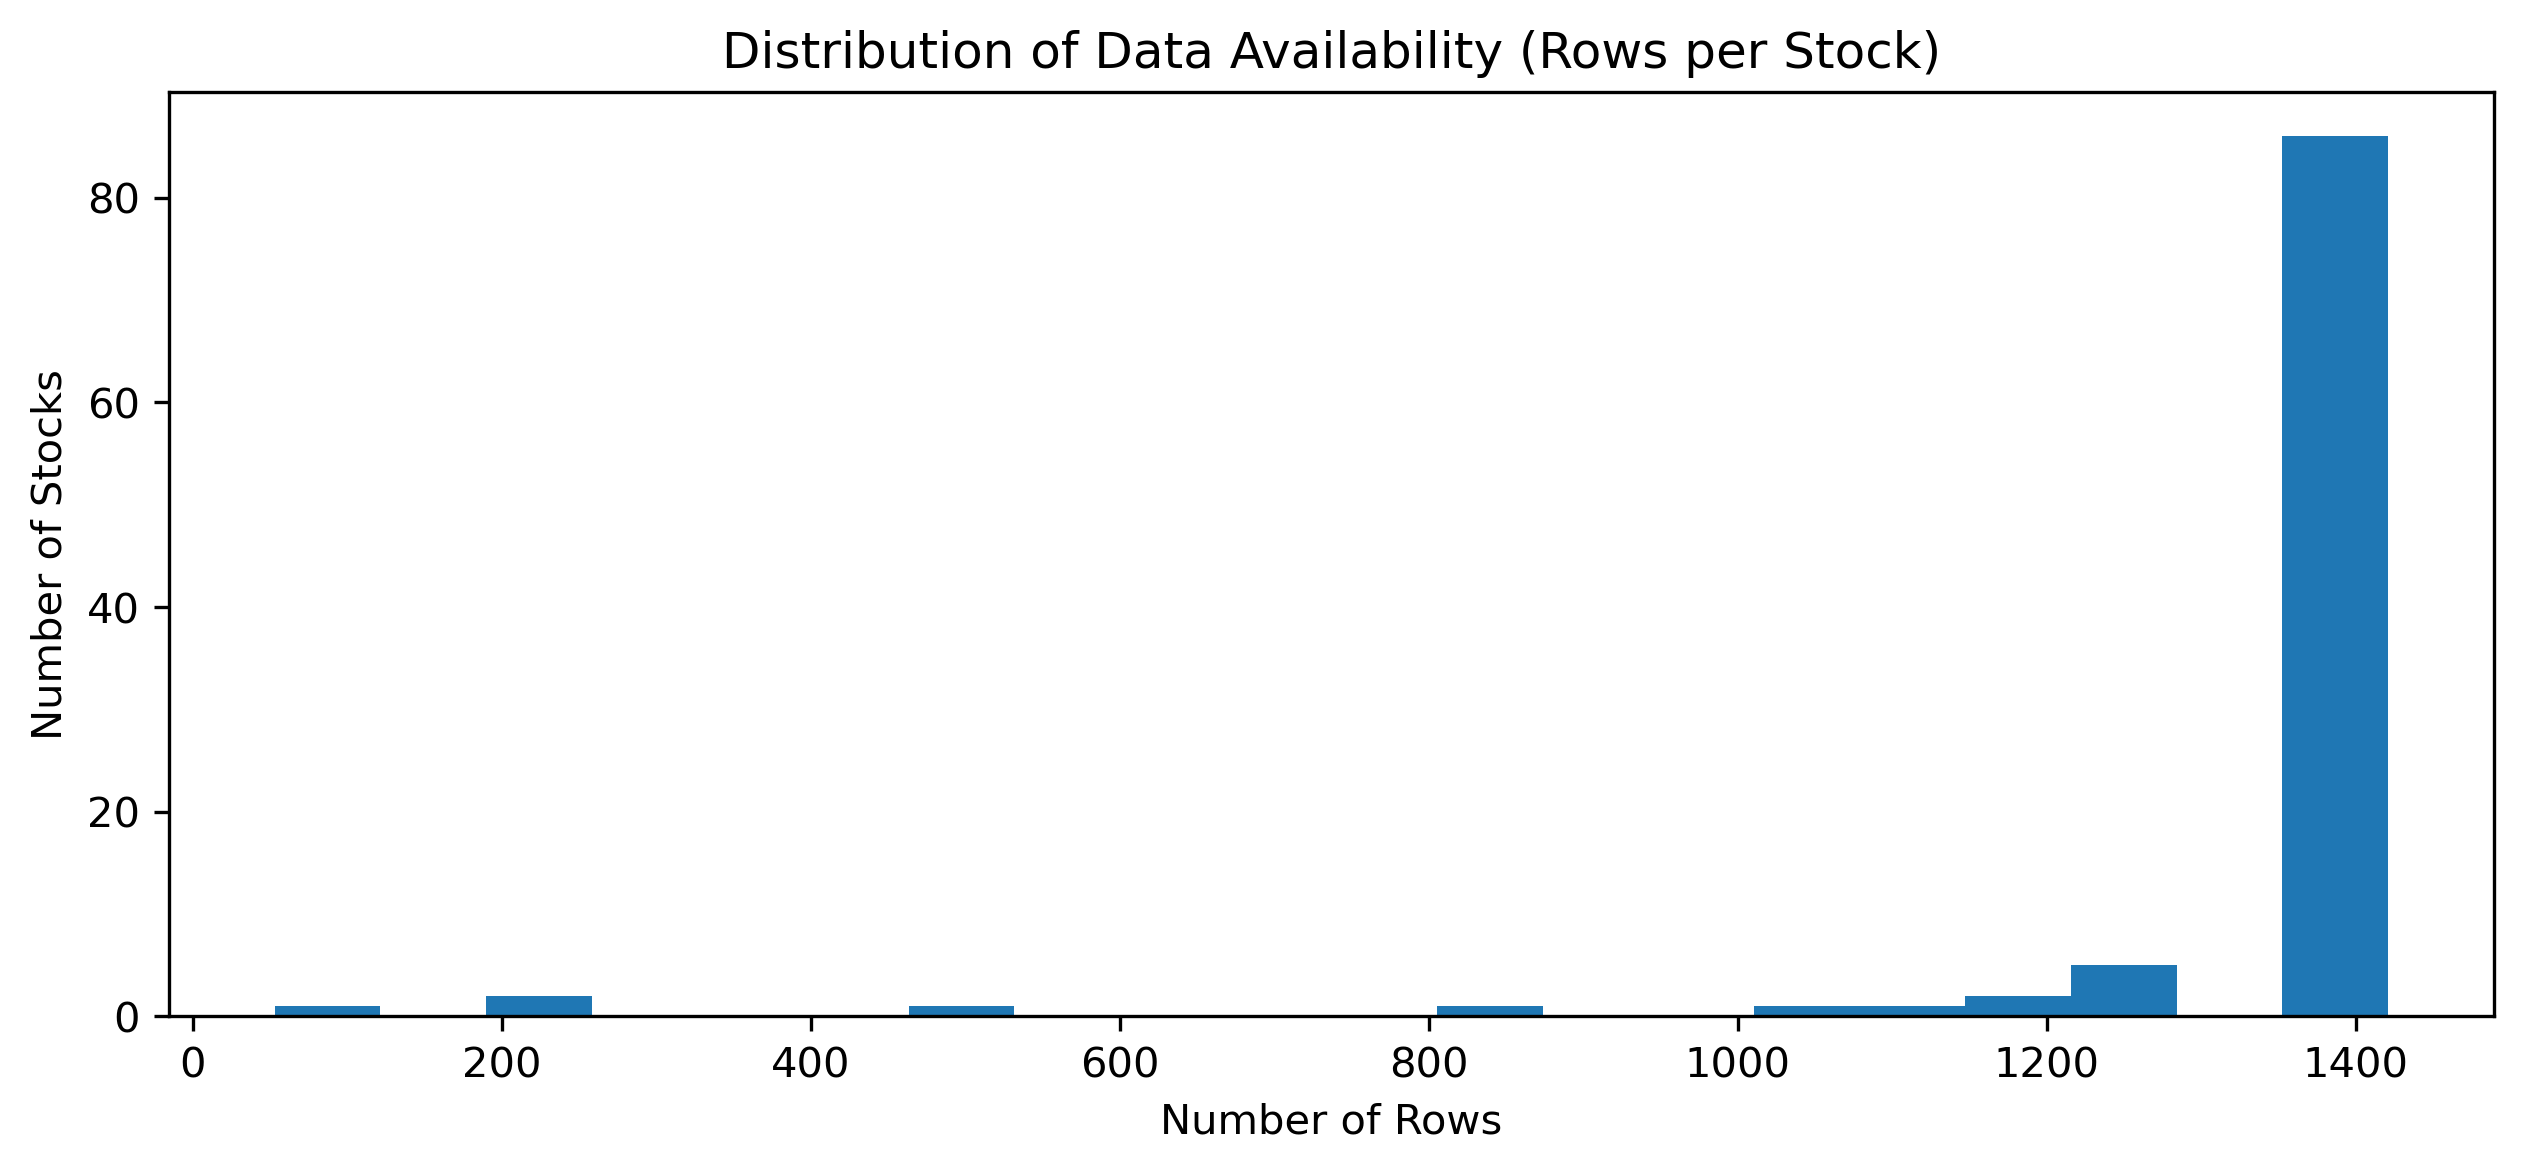

<IPython.core.display.Javascript object>

In [73]:
# -----------------------------------------------------
# Optional: Histogram of Row Distribution
# -----------------------------------------------------
plt.figure(figsize=(10, 4), dpi=300)
plt.hist(availability_df["rows"], bins=20)
plt.title("Distribution of Data Availability (Rows per Stock)")
plt.xlabel("Number of Rows")
plt.ylabel("Number of Stocks")
plt.show()

In [74]:
# -----------------------------------------------------
# Step 6: Filter Stocks With Minimum 1000 Rows
# -----------------------------------------------------

MIN_DAYS = 1000

feature_files = list(FEATURE_DIR.glob("*.csv"))

kept = []
removed = []

for file in feature_files:
    df = pd.read_csv(file)

    if len(df) >= MIN_DAYS:
        kept.append(file.stem)
    else:
        removed.append(file.stem)
        file.unlink()  # delete file

print("\n🗑 Removed Stocks (< 1000 rows):", len(removed))
print("Sample removed:", removed[:10])

print("\n✅ Stocks Remaining:", len(kept))


🗑 Removed Stocks (< 1000 rows): 5
Sample removed: ['BAJAJHFL', 'ENRIN', 'HYUNDAI', 'JIOFIN', 'LICI']

✅ Stocks Remaining: 95


<IPython.core.display.Javascript object>

In [75]:
# -----------------------------------------------------
# Final Dataset Verification
# -----------------------------------------------------

remaining_files = list(FEATURE_DIR.glob("*.csv"))

row_counts = []

for file in remaining_files:
    df = pd.read_csv(file)
    row_counts.append(len(df))

print("\n📊 Remaining Dataset Stats")
print("Stocks:", len(remaining_files))
print("Min rows:", min(row_counts))
print("Median rows:", np.median(row_counts))
print("Max rows:", max(row_counts))


📊 Remaining Dataset Stats
Stocks: 95
Min rows: 1032
Median rows: 1421.0
Max rows: 1421


<IPython.core.display.Javascript object>

In [76]:
print(
    "Total rows across all stocks:",
    sum(len(pd.read_csv(f)) for f in FEATURE_DIR.glob("*.csv")),
)

Total rows across all stocks: 132790


<IPython.core.display.Javascript object>

### 132790 represent sufficient number of rows to start the modelling!

In [77]:
feature_files = list(FEATURE_DIR.glob("*.csv"))

summary = []

for f in feature_files:

    df = pd.read_csv(f)

    ticker = f.stem.replace("_features", "")

    summary.append({"ticker": ticker, "rows": len(df)})

summary_df = pd.DataFrame(summary)

print("Total rows:", summary_df["rows"].sum())
print("Total tickers:", len(summary_df))

summary_df.to_csv("phase2_metadata.csv", index=False)

Total rows: 132790
Total tickers: 95


<IPython.core.display.Javascript object>

In [78]:
combined_df.isnull().sum()

symbol               0
series               0
Date                 0
prevclose            0
Open                 0
High                 0
Low                  0
lastprice            0
Close                0
averageprice         0
Volume               0
turnoverinrs         0
no.oftrades          0
deliverableqty       0
%dlyqttotradedqty    0
news_sent            0
news_count           0
sent_3d              0
sent_7d              0
sent_momentum        0
sent_surprise        0
news_intensity       0
news_event           0
days_since_news      0
news_decay_weight    0
sent_weighted        0
surprise_weighted    0
is_recent_news       0
ret_1d               0
ret_5d               0
ret_21d              0
momentum_1m          0
momentum_3m          0
momentum_6m          0
vol_30d              0
vol_90d              0
rsi_14               0
macd                 0
macd_signal          0
macd_hist            0
ema_fast             0
ema_slow             0
ema_cross            0
volume_chan

<IPython.core.display.Javascript object>

In [79]:
# -----------------------------------------------------------------------------
# Step 7: Visualization of price and parameters variations across the timeframe
# -----------------------------------------------------------------------------

feature_files = list(FEATURE_DIR.glob("*.csv"))
tickers = sorted([f.stem for f in feature_files])

print("Available Tickers:\n")

for t in tickers:
    print(t)

Available Tickers:

ABB
ADANIENSOL
ADANIENT
ADANIGREEN
ADANIPORTS
ADANIPOWER
AMBUJACEM
APOLLOHOSP
ASIANPAINT
AXISBANK
BAJAJ-AUTO
BAJAJFINSV
BAJAJHLDNG
BAJFINANCE
BANKBARODA
BEL
BHARTIARTL
BOSCHLTD
BPCL
BRITANNIA
CANBK
CGPOWER
CHOLAFIN
CIPLA
COALINDIA
DIVISLAB
DLF
DMART
DRREDDY
EICHERMOT
ETERNAL
GAIL
GODREJCP
GRASIM
HAL
HAVELLS
HCLTECH
HDFCBANK
HDFCLIFE
HINDALCO
HINDUNILVR
HINDZINC
ICICIBANK
ICICIGI
INDHOTEL
INDIGO
INFY
IOC
IRFC
ITC
JINDALSTEL
JSWENERGY
JSWSTEEL
KOTAKBANK
LODHA
LT
LTM
M&M
MARUTI
MAXHEALTH
MAZDOCK
MOTHERSON
NAUKRI
NESTLEIND
NTPC
ONGC
PFC
PIDILITIND
PNB
POWERGRID
RECLTD
RELIANCE
SBILIFE
SBIN
SHREECEM
SHRIRAMFIN
SIEMENS
SOLARINDS
SUNPHARMA
TATACONSUM
TATAPOWER
TATASTEEL
TCS
TECHM
TITAN
TMPV
TORNTPHARM
TRENT
TVSMOTOR
ULTRACEMCO
UNITDSPR
VBL
VEDL
WIPRO
ZYDUSLIFE


<IPython.core.display.Javascript object>

### Available Features for Plotting

These are the engineered features that can be visualized using the `plot_feature()` function.

---

#### Price & Volume

**Open**  : Opening price of the stock for the trading day.

**High**  : Highest price reached during the trading session.

**Low**  : Lowest price reached during the trading session.

**Close**  : Closing price of the stock for the day.

**Volume**  : Total traded quantity of the stock for that day.

---

#### Momentum Features

**momentum_1m**  : Price momentum over the past **1 month (~21 trading days)**.

**momentum_3m**  : Price momentum over the past **3 months (~63 trading days)**.

**momentum_6m**  : Price momentum over the past **6 months (~126 trading days)**.

Momentum features capture **trend strength** and are commonly used in **quantitative alpha strategies**.

---

#### Volatility Feature

**vol_90d**  : Rolling **90-day historical volatility** of returns.

This measures how **unstable the stock price has been over the past three months**.

---

#### Technical Indicators

**rsi_14**  : Relative Strength Index calculated over **14 days**.  
Used to identify **overbought (>70)** or **oversold (<30)** conditions.

**macd_hist**  : MACD Histogram derived from the **difference between MACD and its signal line**.  
Helps detect **trend acceleration and reversals**.

---

#### 📰 News Sentiment Features

**news_sent**  : Daily average sentiment score derived from all news articles for the stock.  
Represents the **overall tone of market perception** on that day.

**news_count**  : Number of news articles published for the stock on that day.  
Acts as a proxy for **market attention and coverage intensity**.

---

#### Rolling Sentiment Signals

**sent_3d**  : Short-term (3-day) rolling sentiment.  
Captures **recent market mood** and immediate reaction to news.

**sent_7d**  : Medium-term (7-day) rolling sentiment.  
Represents the **baseline sentiment trend**.

---

#### Derived Sentiment Features

**sent_momentum**  : Difference between short-term and medium-term sentiment  
(`sent_3d - sent_7d`).  
Indicates **change in sentiment trend**:
- Positive → improving sentiment  
- Negative → deteriorating sentiment  

---

**sent_surprise**  : Difference between current sentiment and its recent historical average.  
Captures **unexpected news impact**:
- High positive → better-than-expected news  
- High negative → worse-than-expected news  

This is often a **highly predictive feature** in quant models.

---

**news_intensity**  : Ratio of current news volume to its recent average.  
Measures **attention spikes**:
- High values → unusual increase in news coverage  
- Indicates potential **event-driven price movement**

---

#### Key Insight

- Price features capture **what the market did**  
- Technical indicators capture **how it is behaving**  
- News features capture **why it might move next**

Combining these provides a more **holistic view for alpha generation**.

In [80]:
import pandas as pd
import plotly.graph_objects as go


def plot_feature(ticker, feature, start_date=None, end_date=None, years=None):

    file_path = FEATURE_DIR / f"{ticker}.csv"

    # Load dataset
    df = pd.read_csv(file_path)

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")

    # If years argument is used
    if years is not None:
        end_date = df["Date"].max()
        start_date = end_date - pd.DateOffset(years=years)

    # Apply filters
    if start_date:
        df = df[df["Date"] >= pd.to_datetime(start_date)]

    if end_date:
        df = df[df["Date"] <= pd.to_datetime(end_date)]

    # Validate feature
    if feature not in df.columns:
        raise ValueError(f"{feature} not found in dataset")

    # Plot using Plotly
    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[feature],
            mode="lines",
            line=dict(color="black", width=1.5),
            name=feature,
        )
    )

    fig.update_layout(
        title=f"{ticker} - {feature}",
        template="plotly_white",
        hovermode="x unified",
        width=1100,
        height=450,
        margin=dict(l=80, r=80, t=60, b=60),
        xaxis=dict(title="Date", showline=True, linecolor="black", mirror=True),
        yaxis=dict(title=feature, showline=True, linecolor="black", mirror=True),
    )

    fig.show()

<IPython.core.display.Javascript object>

In [81]:
plot_feature("ADANIPORTS", "rsi_14", years=2)

<IPython.core.display.Javascript object>

In [82]:
plot_feature(
    ticker="TCS", feature="vol_90d", start_date="2022-01-01", end_date="2024-01-13"
)

<IPython.core.display.Javascript object>